In [1]:
# Install FRED library
!pip install fredapi -q

from fredapi import Fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# FRED requires a free API key
# Get one in 2 minutes at: https://fred.stlouisfed.org/docs/api/api_key.html
# Sign up → confirm email → copy your key

API_KEY = '99f2b31d3b6c4d9aec465e8aae664b28'
fred = Fred(api_key=API_KEY)

print("FRED connection ready")

FRED connection ready


In [2]:
!pip install wbdata -q
import wbdata

# World Bank indicators
indicators = {
    'FP.CPI.TOTL.ZG': 'inflation_rate',
    'PA.NUS.FCRF': 'ruble_per_usd',
    'FI.RES.TOTL.CD': 'total_reserves_usd',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'NY.GDP.PETR.RT.ZS': 'oil_rents_pct_gdp',
    'BN.CAB.XOKA.CD': 'current_account_balance',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp'
}

# Fetch for Russia
df_wb = wbdata.get_dataframe(indicators, country='RU')
df_wb = df_wb.sort_index()
df_wb = df_wb[df_wb.index >= '2000']

print("World Bank data loaded:")
print(df_wb.shape)
display(df_wb.tail(10))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 7.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
World Bank data loaded:
(26, 8)


,inflation_rate,ruble_per_usd,total_reserves_usd,gdp_growth,unemployment_rate,oil_rents_pct_gdp,current_account_balance,govt_debt_pct_gdp
date,,,,,,,,
2016,7.042437,67.055933,3.770522e+11,0.193690,5.591,5.006137,2.446881e+10,14.241740
2017,3.683331,58.342801,4.327305e+11,1.825790,5.238,6.228645,3.217863e+10,16.325374
2018,2.878314,62.668133,4.686452e+11,2.807245,4.871,9.654761,1.156799e+11,16.168579
2019,4.472026,64.737658,5.551795e+11,2.198076,4.513,8.493707,6.562725e+10,17.276048
2020,3.382198,72.104908,5.967699e+11,-2.653655,5.620,4.707771,3.537269e+10,22.992021
2021,6.694459,73.654350,6.322418e+11,5.866492,4.749,9.671594,1.249530e+11,21.028751
2022,13.743680,68.484942,5.817100e+11,-1.435882,3.867,NaN,2.377348e+11,19.288476
2023,5.865719,85.162008,5.972171e+11,4.082525,3.076,NaN,4.939645e+10,18.503223
2024,8.434864,92.552400,NaN,4.344375,2.430,NaN,6.336035e+10,NaN


In [3]:
# Drop oil rents column
df_wb = df_wb.drop(columns=['oil_rents_pct_gdp'])

# Keep 2000-2023
df_wb = df_wb[df_wb.index <= '2023']
df_wb = df_wb.dropna()

print("World Bank data after cleaning:")
print("Shape:", df_wb.shape)
print("Years:", df_wb.index.min(), "to", df_wb.index.max())

# Now add Brent crude from FRED — annual average
brent = fred.get_series('DCOILBRENTEU',
                         observation_start='2000-01-01')
brent_annual = brent.resample('Y').mean()
brent_annual.index = brent_annual.index.year.astype(str)
brent_annual.name = 'brent_crude_usd'

# Merge
df_final = df_wb.join(brent_annual, how='left')
df_final = df_final.dropna()

print("\nFinal dataset:")
print("Shape:", df_final.shape)
print("Years:", df_final.index.min(), "to", df_final.index.max())
print("\nColumns:", df_final.columns.tolist())
display(df_final)

World Bank data after cleaning:
Shape: (22, 7)
Years: 2000 to 2023

Final dataset:
Shape: (22, 8)
Years: 2000 to 2023

Columns: ['inflation_rate', 'ruble_per_usd', 'total_reserves_usd', 'gdp_growth', 'unemployment_rate', 'current_account_balance', 'govt_debt_pct_gdp', 'brent_crude_usd']


/tmp/ipykernel_283/3478026510.py:15: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  brent_annual = brent.resample('Y').mean()


,inflation_rate,ruble_per_usd,total_reserves_usd,gdp_growth,unemployment_rate,current_account_balance,govt_debt_pct_gdp,brent_crude_usd
date,,,,,,,,
2000,20.798761,28.129167,2.765627e+10,10.000067,10.581,4.538238e+10,62.148889,28.660672
2001,21.477007,29.168525,3.630252e+10,5.100051,8.978,3.205382e+10,48.983615,24.455720
2002,15.788731,31.348483,4.832564e+10,4.699992,7.875,2.747295e+10,41.352717,24.993255
2005,12.685304,28.284442,1.822721e+11,6.399965,7.124,8.438875e+10,16.660868,54.574553
2006,9.668655,27.190958,3.037732e+11,8.200068,7.055,9.231557e+10,9.891073,65.161765
2007,9.007299,25.580845,4.788223e+11,8.499978,6.002,7.219302e+10,7.158430,72.441160
2008,14.110768,24.852875,4.262788e+11,5.199969,6.205,1.039354e+11,6.495287,96.944348
2009,11.647330,31.740358,4.393418e+11,-7.799994,8.301,5.038364e+10,8.697866,61.738770
2010,6.849392,30.367915,4.792223e+11,4.500000,7.407,6.745220e+10,9.098106,79.609444


Correlation Matrix:


,inflation_rate,ruble_per_usd,total_reserves_usd,gdp_growth,unemployment_rate,current_account_balance,govt_debt_pct_gdp,brent_crude_usd
inflation_rate,1.00,-0.45,-0.77,0.22,0.69,0.02,0.63,-0.42
ruble_per_usd,-0.45,1.00,0.54,-0.38,-0.71,0.18,-0.03,-0.07
total_reserves_usd,-0.77,0.54,1.00,-0.37,-0.80,0.37,-0.70,0.66
gdp_growth,0.22,-0.38,-0.37,1.00,0.28,0.00,0.31,-0.07
unemployment_rate,0.69,-0.71,-0.80,0.28,1.00,-0.36,0.57,-0.52
current_account_balance,0.02,0.18,0.37,0.00,-0.36,1.00,-0.22,0.47
govt_debt_pct_gdp,0.63,-0.03,-0.70,0.31,0.57,-0.22,1.00,-0.70
brent_crude_usd,-0.42,-0.07,0.66,-0.07,-0.52,0.47,-0.70,1.00


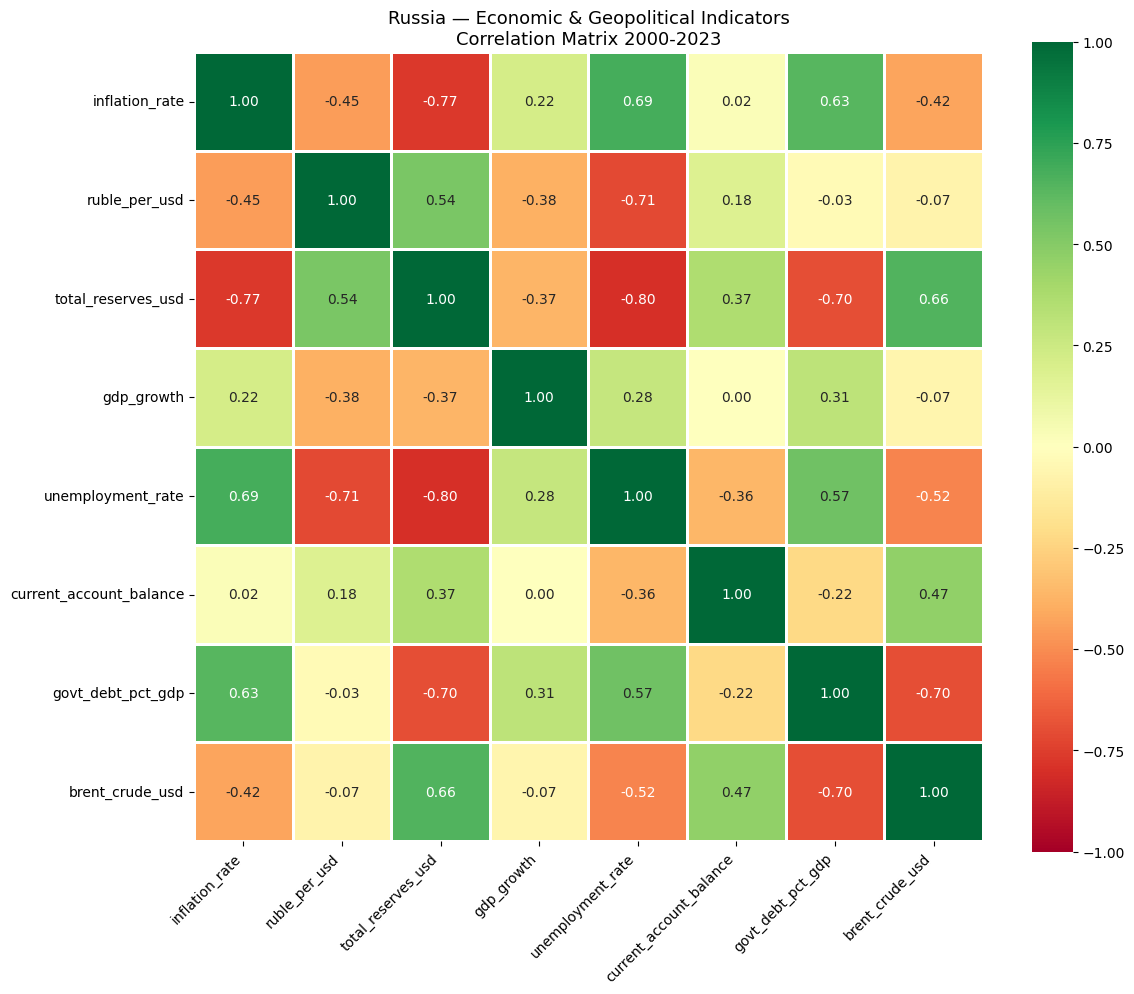

In [4]:
# Convert index to numeric for correlation
df_corr = df_final.copy()
df_corr.index = pd.to_numeric(df_corr.index)

# Calculate correlation matrix
corr_matrix = df_corr.corr()

print("Correlation Matrix:")
display(corr_matrix.round(2))

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=1,
            annot_kws={'size': 10})

plt.title('Russia — Economic & Geopolitical Indicators\nCorrelation Matrix 2000-2023',
          fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

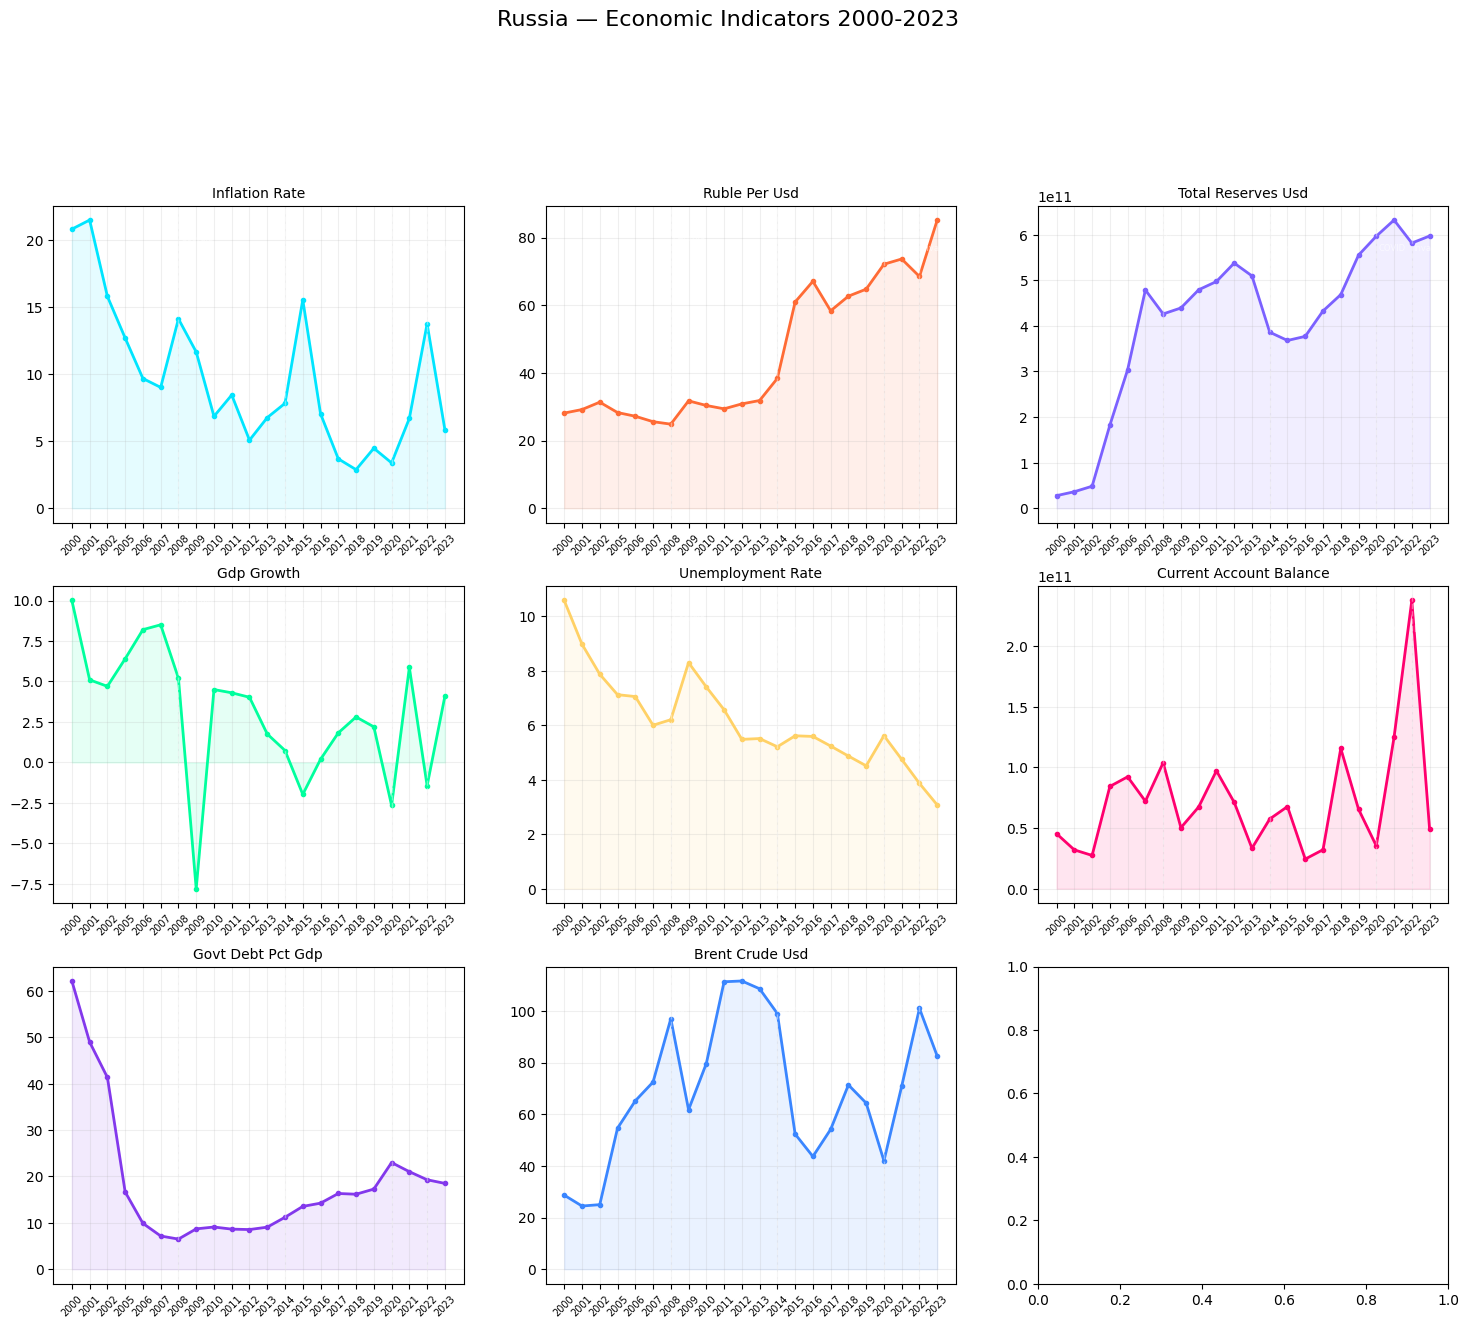

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Russia — Economic Indicators 2000-2023', fontsize=16, y=1.02)

variables = df_final.columns.tolist()
colors = ['#00e5ff', '#ff6b35', '#7b61ff', '#00ff9d',
          '#ffd166', '#ff006e', '#8338ec', '#3a86ff', '#fb5607']

# Key geopolitical events
events = {
    '2008': 'Georgia\nWar',
    '2014': 'Crimea',
    '2020': 'COVID',
    '2022': 'Invasion'
}

for ax, var, color in zip(axes.flatten(), variables, colors):
    years = df_final.index.tolist()
    values = df_final[var].tolist()

    ax.plot(years, values, color=color, linewidth=2, marker='o', markersize=3)
    ax.fill_between(years, values, alpha=0.1, color=color)

    # Add event lines
    for year, label in events.items():
        if year in years:
            idx = years.index(year)
            ax.axvline(x=idx, color='white',
                      linewidth=1, linestyle='--', alpha=0.4)
            ax.text(idx + 0.1, ax.get_ylim()[1] * 0.85,
                   label, color='white', fontsize=6, alpha=0.6)

    # Clean up title
    title = var.replace('_', ' ').title()
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(alpha=0.2)

    # Show every 4th year on x axis to avoid cr

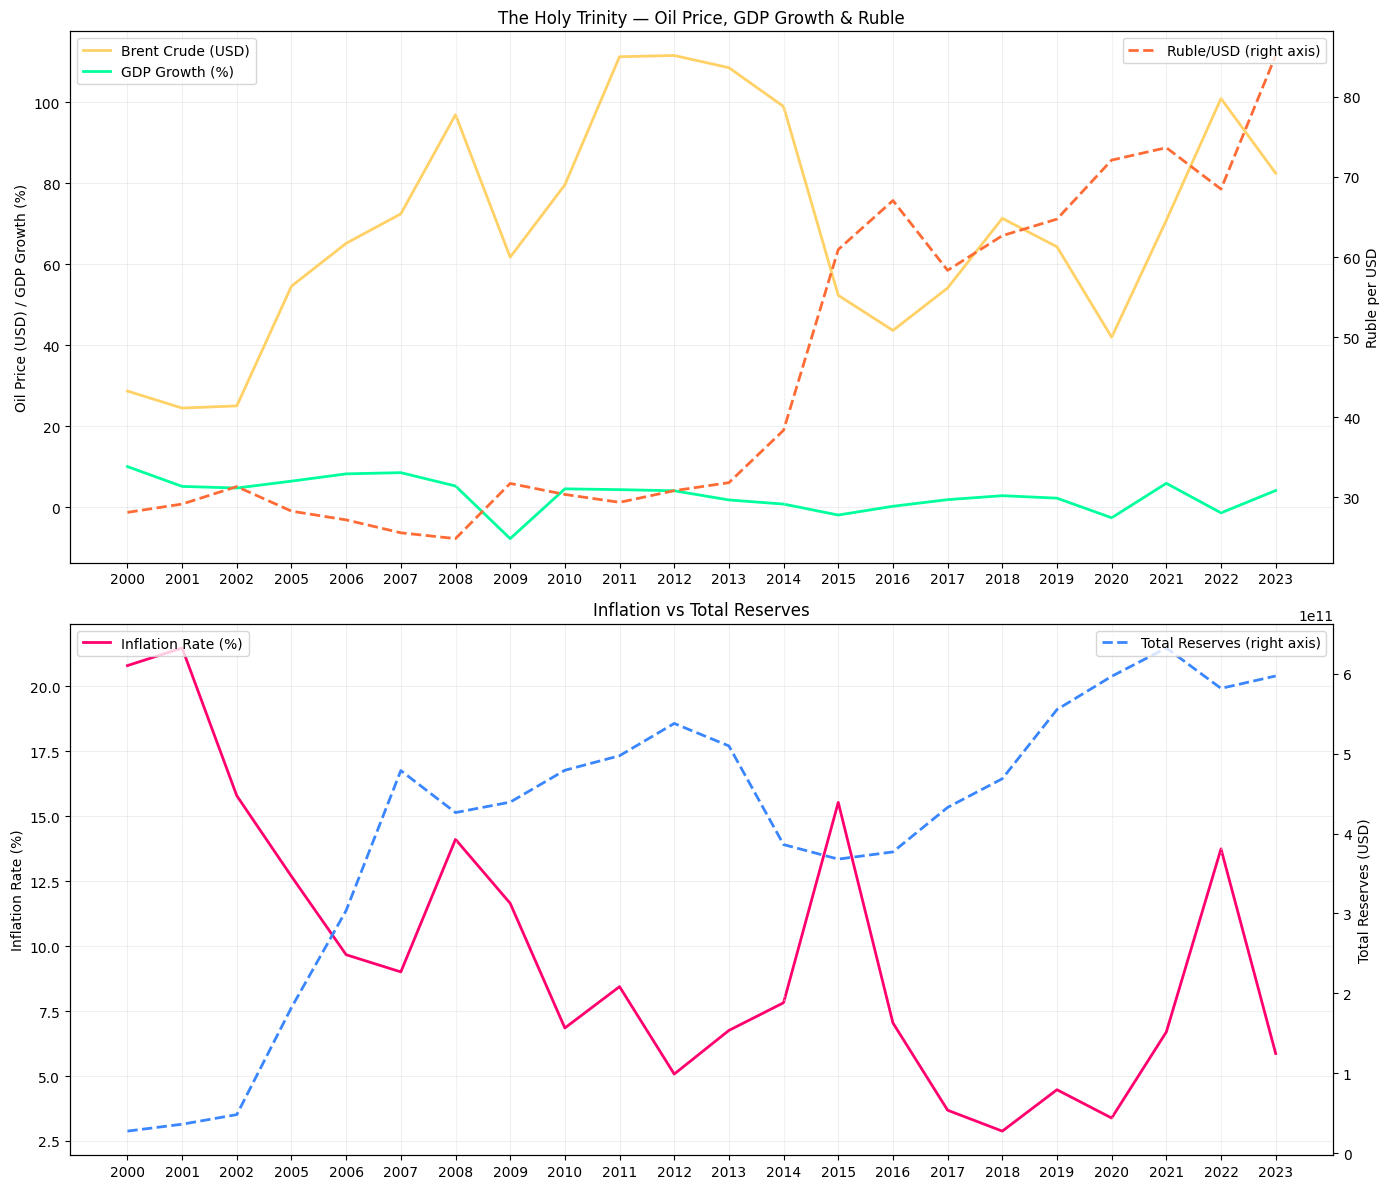

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
years = df_final.index.tolist()

# Plot 1 — The holy trinity: oil, ruble, GDP
ax1 = axes[0]
ax1_twin = ax1.twinx()

ax1.plot(years, df_final['brent_crude_usd'],
         color='#ffd166', linewidth=2, label='Brent Crude (USD)')
ax1.plot(years, df_final['gdp_growth'],
         color='#00ff9d', linewidth=2, label='GDP Growth (%)')
ax1_twin.plot(years, df_final['ruble_per_usd'],
              color='#ff6b35', linewidth=2,
              linestyle='--', label='Ruble/USD (right axis)')

ax1.set_title('The Holy Trinity — Oil Price, GDP Growth & Ruble', fontsize=12)
ax1.set_ylabel('Oil Price (USD) / GDP Growth (%)')
ax1_twin.set_ylabel('Ruble per USD')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')
ax1.grid(alpha=0.2)

# Add event markers
for year, label in events.items():
    if year in years:
        idx = years.index(year)
        ax1.axvline(x=idx, color='white', linewidth=1,
                   linestyle=':', alpha=0.5)
        ax1.text(idx + 0.1, ax1.get_ylim()[1] * 0.9,
                label, color='white', fontsize=8)

# Plot 2 — Inflation and reserves
ax2 = axes[1]
ax2_twin = ax2.twinx()

ax2.plot(years, df_final['inflation_rate'],
         color='#ff006e', linewidth=2, label='Inflation Rate (%)')
ax2_twin.plot(years, df_final['total_reserves_usd'],
              color='#3a86ff', linewidth=2,
              linestyle='--', label='Total Reserves (right axis)')

ax2.set_title('Inflation vs Total Reserves', fontsize=12)
ax2.set_ylabel('Inflation Rate (%)')
ax2_twin.set_ylabel('Total Reserves (USD)')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(alpha=0.2)

for year, label in events.items():
    if year in years:
        idx = years.index(year)
        ax2.axvline(x=idx, color='white', linewidth=1,
                   linestyle=':', alpha=0.5)
        ax2.text(idx + 0.1, ax2.get_ylim()[1] * 0.9,
                label, color='white', fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# Med bare 20 datapunkter bruker vi Leave-One-Out cross validation
# istedenfor vanlig train/test split — forklarer jeg nedenfor

# Features: alle variabler unntatt GDP-vekst
# Target: GDP-vekst neste år (shifted med 1 år)
df_model = df_final.copy()
df_model.index = pd.to_numeric(df_model.index)

# Lag GDP-vekst ett år frem — vi predikerer NESTE års vekst
df_model['gdp_growth_next_year'] = df_model['gdp_growth'].shift(-1)
df_model = df_model.dropna()

features = ['brent_crude_usd', 'ruble_per_usd', 'inflation_rate',
            'total_reserves_usd', 'unemployment_rate',
            'current_account_balance', 'govt_debt_pct_gdp']

X = df_model[features]
y = df_model['gdp_growth_next_year']

print(f"Treningsdata: {len(X)} år")
print(f"Features: {features}")

# Leave-One-Out cross validation
loo = LeaveOneOut()
predictions = []
actuals = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    predictions.append(pred[0])
    actuals.append(y_test.values[0])

mae = mean_absolute_error(actuals, predictions)
print(f"\nMean Absolute Error: {mae:.2f}%")
print(f"Gjennomsnittlig faktisk GDP-vekst: {np.mean(actuals):.2f}%")
print(f"Feil som % av gjennomsnitt: {mae/abs(np.mean(actuals))*100:.1f}%")

Treningsdata: 21 år
Features: ['brent_crude_usd', 'ruble_per_usd', 'inflation_rate', 'total_reserves_usd', 'unemployment_rate', 'current_account_balance', 'govt_debt_pct_gdp']

Mean Absolute Error: 3.16%
Gjennomsnittlig faktisk GDP-vekst: 2.69%
Feil som % av gjennomsnitt: 117.3%


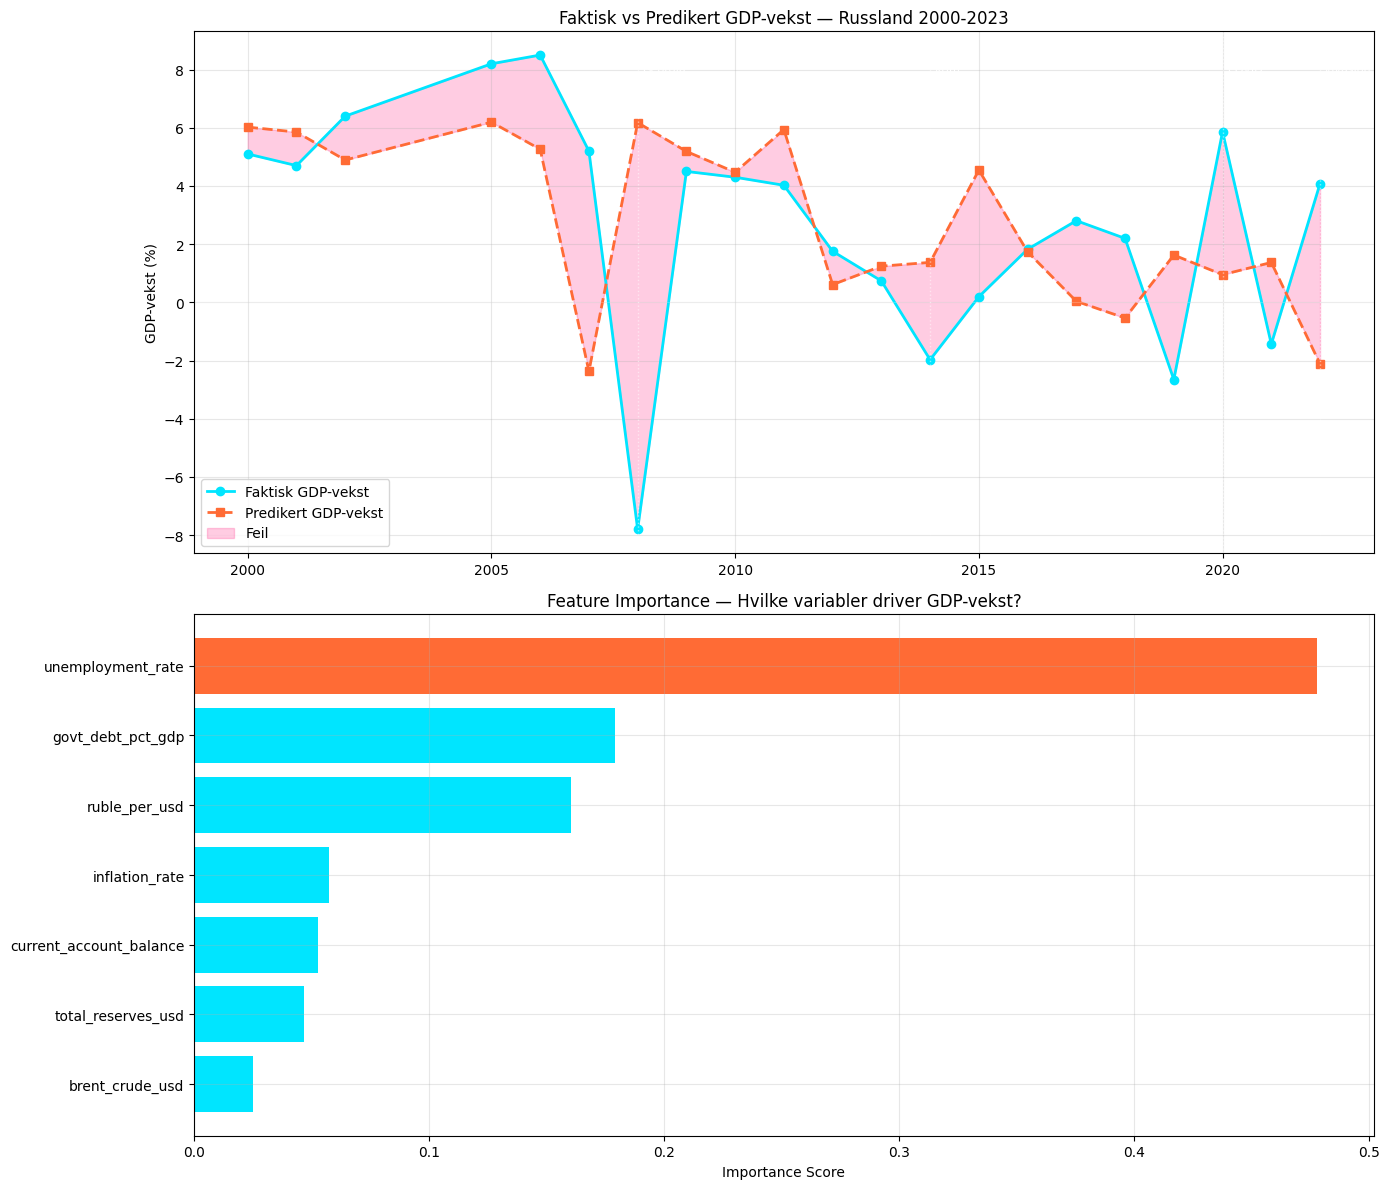

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

years = df_model.index.tolist()

# Plot 1 — Faktisk vs predikert
axes[0].plot(years, actuals, color='#00e5ff', linewidth=2,
             marker='o', markersize=6, label='Faktisk GDP-vekst')
axes[0].plot(years, predictions, color='#ff6b35', linewidth=2,
             marker='s', markersize=6, linestyle='--',
             label='Predikert GDP-vekst')
axes[0].fill_between(years, actuals, predictions,
                      alpha=0.2, color='#ff006e', label='Feil')
axes[0].axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
axes[0].set_title('Faktisk vs Predikert GDP-vekst — Russland 2000-2023')
axes[0].set_ylabel('GDP-vekst (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Marker geopolitiske events
events = {'2008': 'Georgia', '2014': 'Krim', '2020': 'COVID', '2022': 'Invasjon'}
for year, label in events.items():
    if int(year) in years:
        idx = years.index(int(year))
        axes[0].axvline(x=int(year), color='white',
                       linewidth=1, linestyle=':', alpha=0.5)
        axes[0].text(int(year)+0.1, axes[0].get_ylim()[1]*0.85,
                    label, color='white', fontsize=8)

# Plot 2 — Feature importance
model_full = RandomForestRegressor(n_estimators=100, random_state=42)
model_full.fit(X, y)

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model_full.feature_importances_
}).sort_values('Importance', ascending=False)

colors_imp = ['#ff6b35' if i == 0 else '#00e5ff' for i in range(len(importance))]
axes[1].barh(importance['Feature'], importance['Importance'], color=colors_imp)
axes[1].set_title('Feature Importance — Hvilke variabler driver GDP-vekst?')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

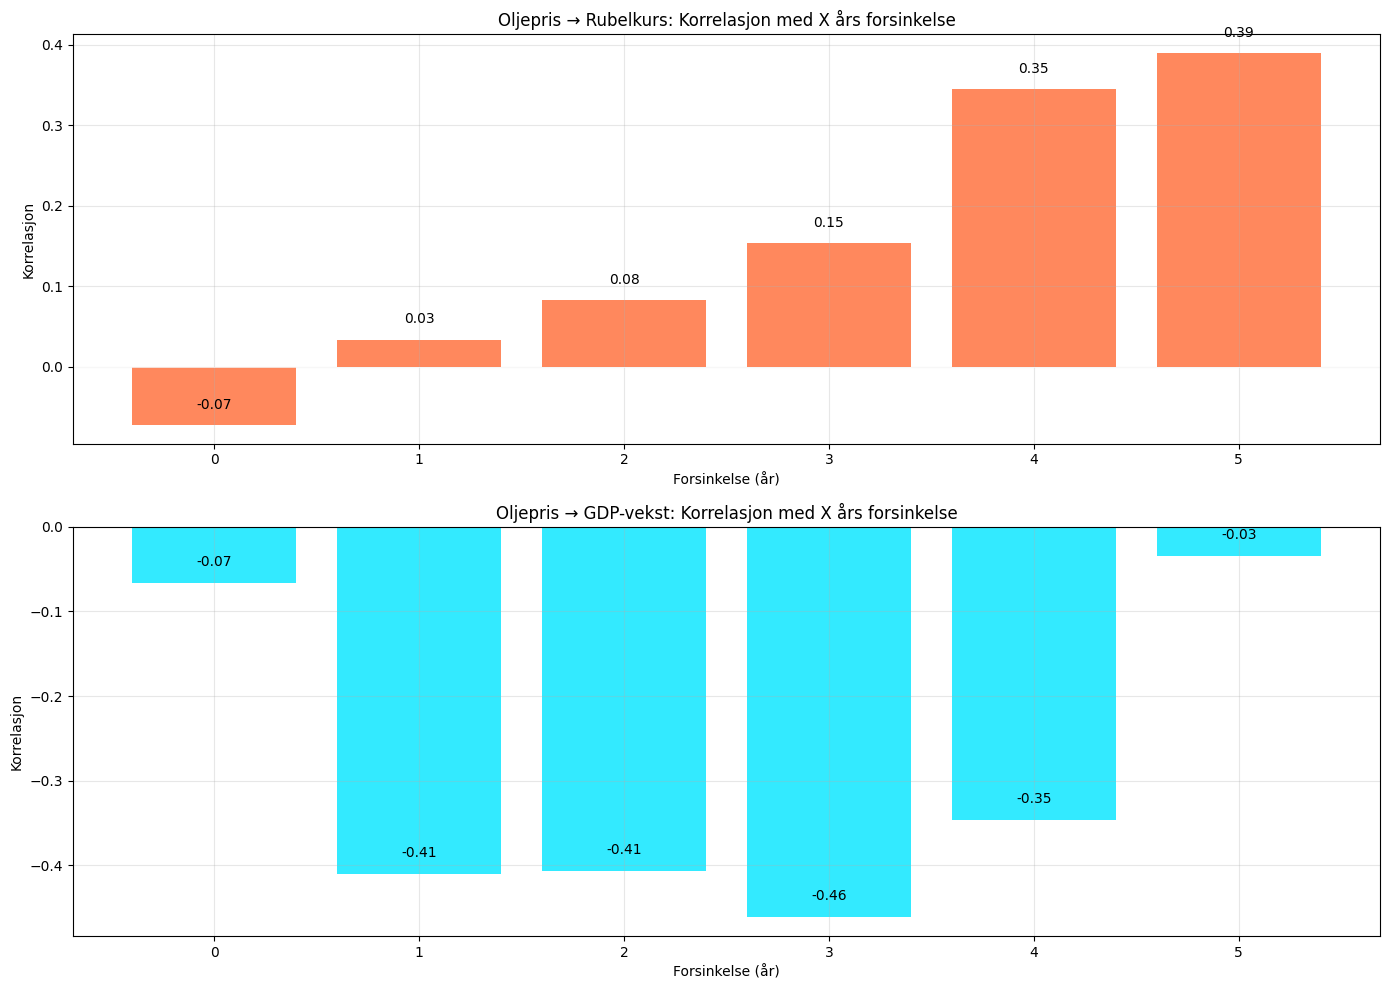

Olje → Ruble korrelasjon per lag:
  Lag 0 år: -0.072
  Lag 1 år: 0.034
  Lag 2 år: 0.083
  Lag 3 år: 0.153
  Lag 4 år: 0.345
  Lag 5 år: 0.390

Olje → GDP korrelasjon per lag:
  Lag 0 år: -0.066
  Lag 1 år: -0.411
  Lag 2 år: -0.407
  Lag 3 år: -0.461
  Lag 4 år: -0.347
  Lag 5 år: -0.035


In [9]:
# Cell 8 — Lagged correlation analyse
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

df_lag = df_final.copy()
df_lag.index = pd.to_numeric(df_lag.index)

# Test lags fra 0 til 5 år
lags = range(0, 6)

# Olje → Ruble
oil_ruble_corr = []
for lag in lags:
    corr = df_lag['brent_crude_usd'].corr(
        df_lag['ruble_per_usd'].shift(-lag)
    )
    oil_ruble_corr.append(corr)

# Olje → GDP
oil_gdp_corr = []
for lag in lags:
    corr = df_lag['brent_crude_usd'].corr(
        df_lag['gdp_growth'].shift(-lag)
    )
    oil_gdp_corr.append(corr)

# Plot
axes[0].bar(lags, oil_ruble_corr, color='#ff6b35', alpha=0.8)
axes[0].axhline(y=0, color='white', linewidth=0.5)
axes[0].set_title('Oljepris → Rubelkurs: Korrelasjon med X års forsinkelse')
axes[0].set_xlabel('Forsinkelse (år)')
axes[0].set_ylabel('Korrelasjon')
axes[0].grid(alpha=0.3)

for i, v in enumerate(oil_ruble_corr):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

axes[1].bar(lags, oil_gdp_corr, color='#00e5ff', alpha=0.8)
axes[1].axhline(y=0, color='white', linewidth=0.5)
axes[1].set_title('Oljepris → GDP-vekst: Korrelasjon med X års forsinkelse')
axes[1].set_xlabel('Forsinkelse (år)')
axes[1].set_ylabel('Korrelasjon')
axes[1].grid(alpha=0.3)

for i, v in enumerate(oil_gdp_corr):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Olje → Ruble korrelasjon per lag:")
for lag, corr in zip(lags, oil_ruble_corr):
    print(f"  Lag {lag} år: {corr:.3f}")

print("\nOlje → GDP korrelasjon per lag:")
for lag, corr in zip(lags, oil_gdp_corr):
    print(f"  Lag {lag} år: {corr:.3f}")